In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import catboost as cb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
warnings.filterwarnings("ignore")

In [4]:

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# =========================
# 2. LOAD TRAIN / TEST
# =========================
train_path = "C:/Users/DELL/Desktop/heart_disease/train.csv"
test_path  = "C:/Users/DELL/Desktop/heart_disease/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())


Train shape: (630000, 21)
Test shape: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [5]:
# Basic info
print("Train info:")
train.info()

print("\nTest info:")
test.info()



Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  objec

In [6]:
# Missing values
print("\nMissing values in train:")
print(train.isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
print(test.isnull().sum().sort_values(ascending=False))




Missing values in train:
id                         0
Crop_Type                  0
Region                     0
Previous_Irrigation_mm     0
Mulching_Used              0
Field_Area_hectare         0
Water_Source               0
Irrigation_Type            0
Season                     0
Crop_Growth_Stage          0
Wind_Speed_kmh             0
Soil_Type                  0
Sunlight_Hours             0
Rainfall_mm                0
Humidity                   0
Temperature_C              0
Electrical_Conductivity    0
Organic_Carbon             0
Soil_Moisture              0
Soil_pH                    0
Irrigation_Need            0
dtype: int64

Missing values in test:
id                         0
Soil_Type                  0
Previous_Irrigation_mm     0
Mulching_Used              0
Field_Area_hectare         0
Water_Source               0
Irrigation_Type            0
Season                     0
Crop_Growth_Stage          0
Crop_Type                  0
Wind_Speed_kmh             0
Sunlight

In [7]:
# Duplicates
print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())




Duplicate rows in train: 0
Duplicate rows in test: 0


In [8]:
# Summary stats for numerical columns
display(train.describe())

# Unique values for categorical columns
cat_cols = train.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts().head())

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000



Soil_Type: 4 unique values
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: Soil_Type, dtype: int64

Crop_Type: 6 unique values
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Name: Crop_Type, dtype: int64

Crop_Growth_Stage: 4 unique values
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: Crop_Growth_Stage, dtype: int64

Season: 3 unique values
Kharif    216561
Rabi      208033
Zaid      205406
Name: Season, dtype: int64

Irrigation_Type: 4 unique values
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: Irrigation_Type, dtype: int64

Water_Source: 4 unique values
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: Water_Source, dtype: int64

Mulching_Used: 2 unique values
No     316453
Yes    313547
Name: Mulching_Used, dtype: int64

Region: 5 unique values
South      134809
West       131189
Ea

EDA

In [9]:
target = "Irrigation_Need"

# feature lists
num_cols = [c for c in train.select_dtypes(include=np.number).columns if c != "id"]
cat_cols = [c for c in train.select_dtypes(include="object").columns if c != target]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("\nTarget classes:")
print(train[target].value_counts())
print("\nTarget percentages:")
print((train[target].value_counts(normalize=True) * 100).round(2))

Numeric columns: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical columns: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Target classes:
Low       369917
Medium    239074
High       21009
Name: Irrigation_Need, dtype: int64

Target percentages:
Low       58.72
Medium    37.95
High       3.33
Name: Irrigation_Need, dtype: float64


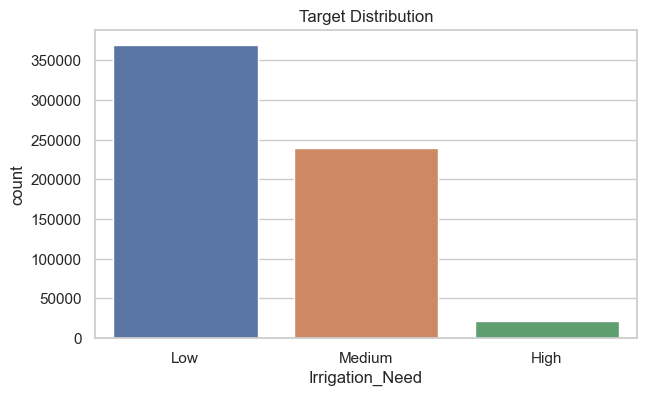

In [10]:
# =========================
# 2. TARGET DISTRIBUTION
# =========================
plt.figure(figsize=(7,4))
order = train[target].value_counts().index
sns.countplot(data=train, x=target, order=order)
plt.title("Target Distribution")
plt.show()

Soil_pH               Soil_Moisture                 \
                   mean median    std          mean median     std   
Irrigation_Need                                                      
High              6.578   6.59  0.979        17.670  17.09   7.480   
Low               6.488   6.46  0.917        43.306  44.01  13.421   
Medium            6.466   6.40  0.926        29.744  23.89  16.625   

                Organic_Carbon               Electrical_Conductivity         \
                          mean median    std                    mean median   
Irrigation_Need                                                               
High                     0.924   0.91  0.374                   1.691   1.65   
Low                      0.921   0.90  0.366                   1.732   1.72   
Medium                   0.926   0.93  0.365                   1.769   1.76   

                       Temperature_C               Humidity                 \
                   std          mean median    std     mean median     std   
Irrigation_Need                                                              
High             0.891        34.568  34.91  5.421   61.120  62.85  19.243   
Low              0.961        25.348  24.54  8.365   61.949  61.77  19.913   
Medium           0.943        28.887  30.66  8.503   61.005  61.44  19.414   

                Rainfall_mm                   Sunlight_Hours                \
                       mean   median      std           mean median    std   
Irrigation_Need                                                              
High                989.157   764.95  800.312          7.463   7.48  2.031   
Low                1500.534  1498.88  584.805          7.511   7.58  2.000   
Medium             1444.475  1463.59  618.450          7.521   7.61  1.995   

                Wind_Speed_kmh               Field_Area_hectare                \
                          mean median    std               mean median    std   
Irrigation_Need                                                                 
High                    14.643  15.01  4.118              7.530   7.49  4.477   
Low                      9.216   8.42  5.632              7.447   7.25  4.197   
Medium                  11.794  12.52  5.389              7.626   7.56  4.225   

                Previous_Irrigation_mm                 
                                  mean median     std  
Irrigation_Need                                        
High                            63.053  66.65  32.197  
Low                             61.718  59.38  35.548  
Medium                          63.182  62.20  32.295

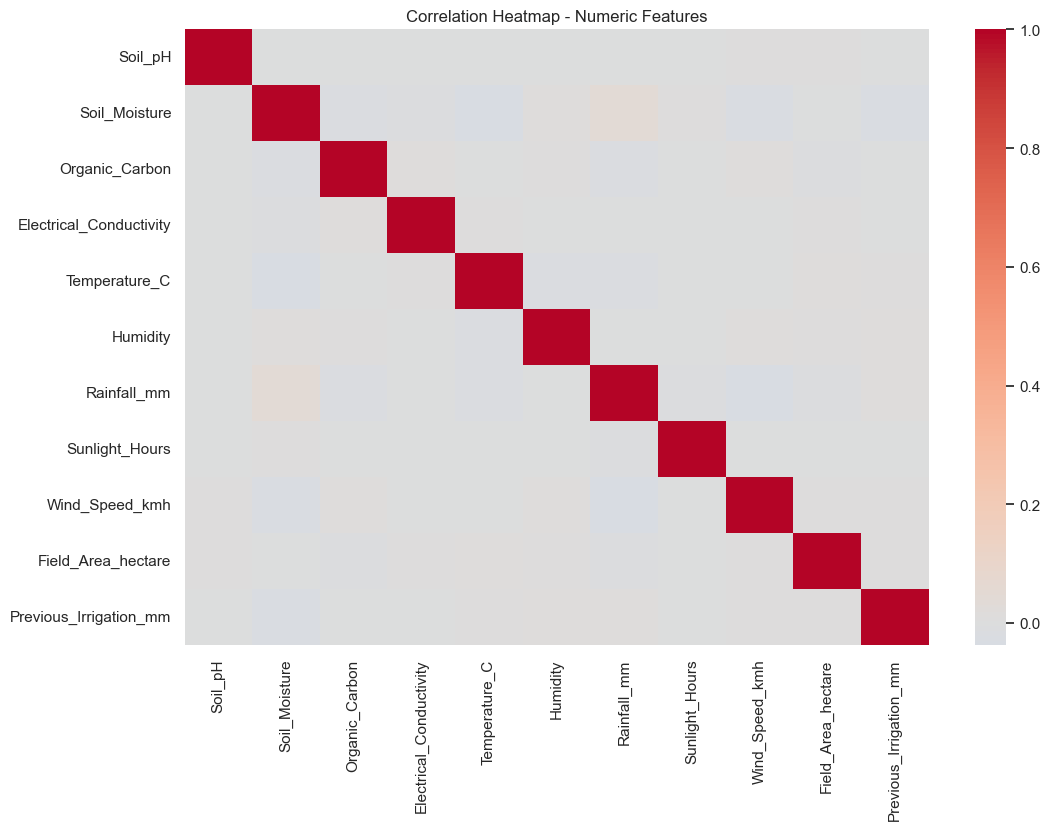

In [11]:
# =========================
# 3. NUMERIC SUMMARY
# =========================
display(train.groupby(target)[num_cols].agg(["mean", "median", "std"]).round(3))

plt.figure(figsize=(12, 8))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

,feature,F_stat,p_value,eta_squared
1,Soil_Moisture,82555.917859,0.000000e+00,0.207659
8,Wind_Speed_kmh,22514.094175,0.000000e+00,0.066706
4,Temperature_C,22043.759085,0.000000e+00,0.065404
6,Rainfall_mm,7241.631185,0.000000e+00,0.022473
5,Humidity,172.297278,1.558475e-75,0.000547
0,Soil_pH,158.296161,1.862596e-69,0.000502
3,Electrical_Conductivity,146.958066,1.555271e-64,0.000466
10,Previous_Irrigation_mm,137.644058,1.717915e-60,0.000437
9,Field_Area_hectare,130.155193,3.061912e-57,0.000413
2,Organic_Carbon,16.167903,9.518080e-08,0.000051


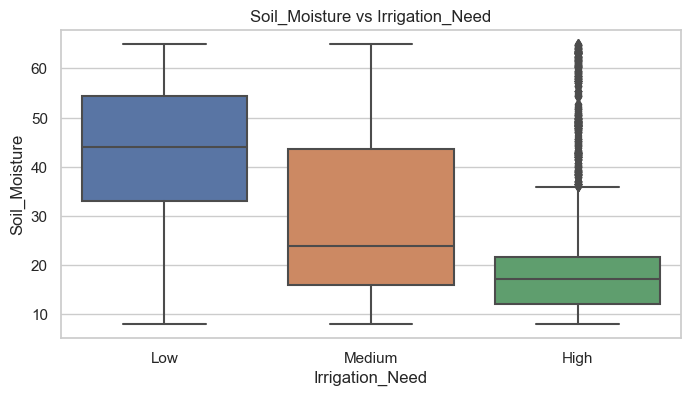

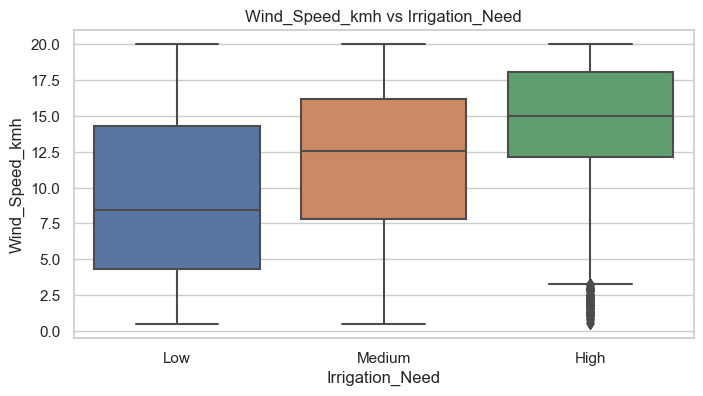

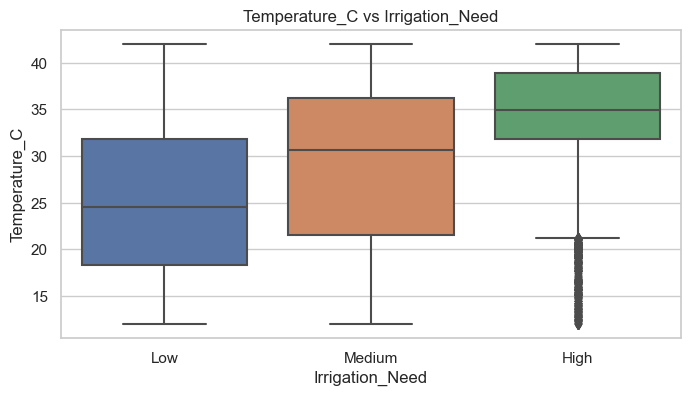

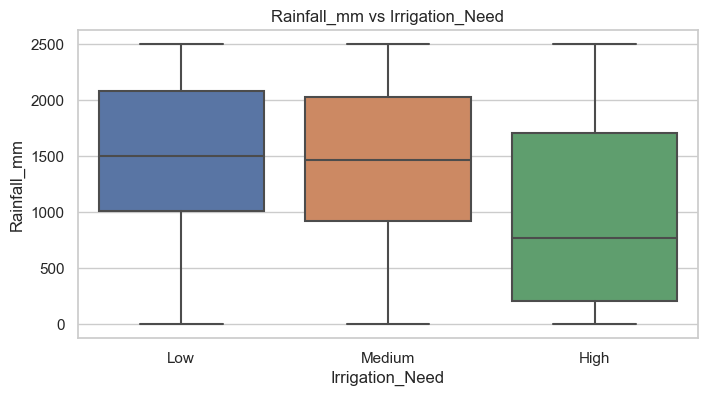

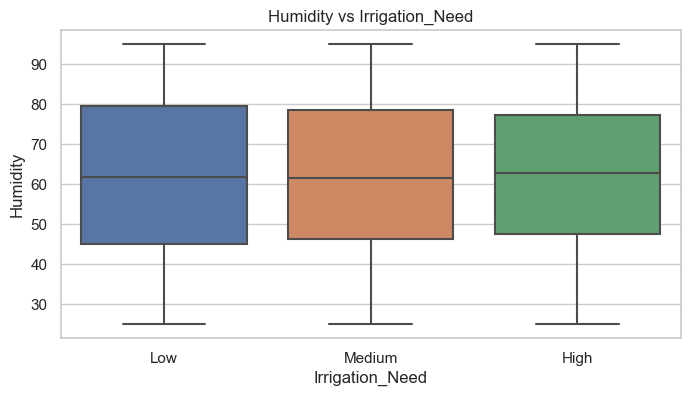

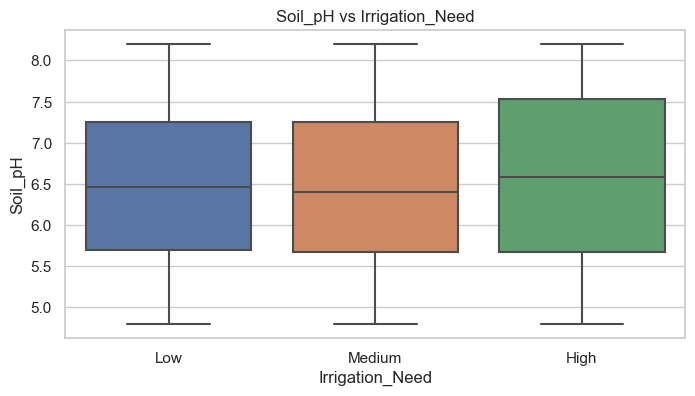

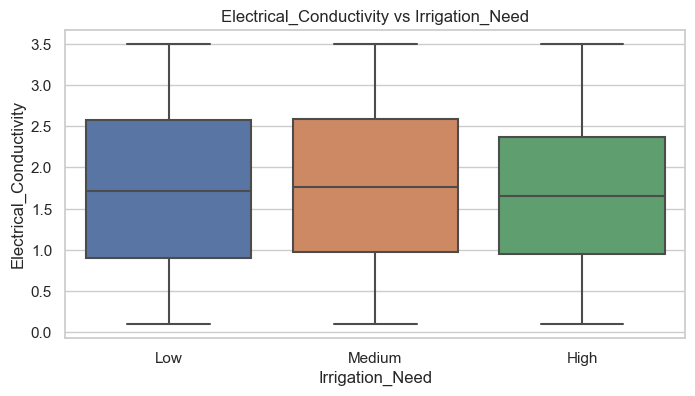

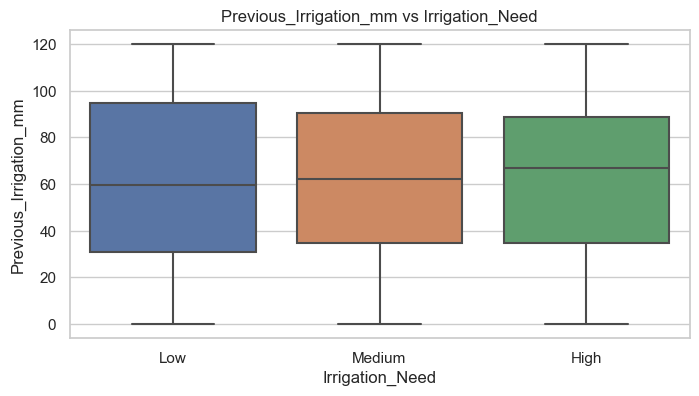

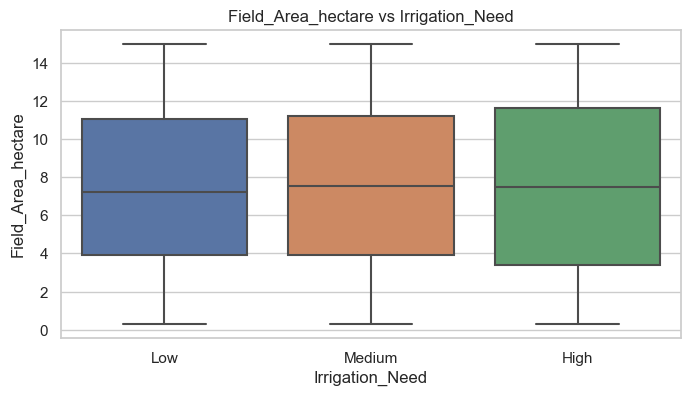

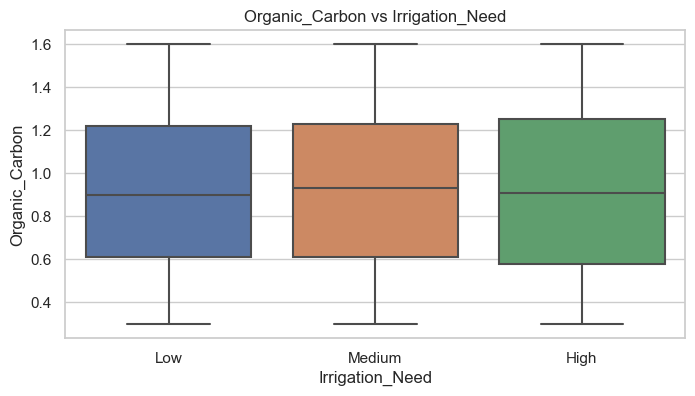

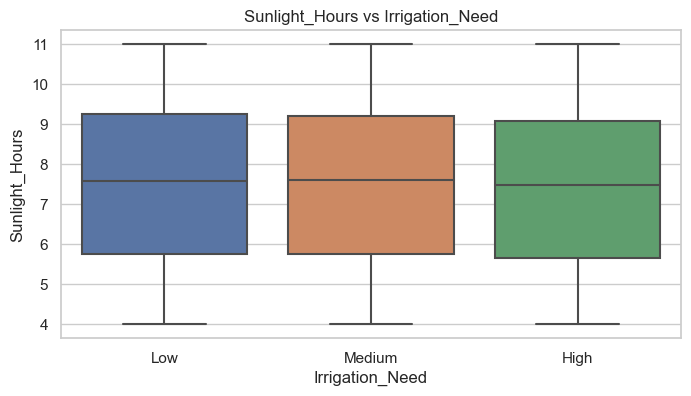

In [12]:
# =========================
# 4. NUMERIC FEATURES VS TARGET
#    Boxplots + ANOVA + ETA SQUARED
# =========================
def anova_eta_squared(df, feature, target_col):
    groups = [g[feature].dropna().values for _, g in df.groupby(target_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean = df[feature].mean()
    ss_between = sum(len(g) * (df.loc[df[target_col] == grp, feature].mean() - grand_mean) ** 2
                     for grp, g in df.groupby(target_col))
    ss_total = ((df[feature] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total if ss_total != 0 else 0
    return f_stat, p_val, eta_sq

anova_results = []
for col in num_cols:
    f_stat, p_val, eta_sq = anova_eta_squared(train, col, target)
    anova_results.append([col, f_stat, p_val, eta_sq])

anova_df = pd.DataFrame(anova_results, columns=["feature", "F_stat", "p_value", "eta_squared"])
anova_df = anova_df.sort_values("eta_squared", ascending=False)

display(anova_df)

for col in anova_df["feature"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=train, x=target, y=col, order=order)
    plt.title(f"{col} vs {target}")
    plt.show()

,feature,chi2,p_value,cramers_v
2,Crop_Growth_Stage,194378.520268,0.000000e+00,0.392771
6,Mulching_Used,56876.904242,0.000000e+00,0.300468
5,Water_Source,1642.705118,0.000000e+00,0.036107
4,Irrigation_Type,1096.452744,1.221198e-233,0.029499
1,Crop_Type,1094.944060,6.491332e-229,0.029479
0,Soil_Type,406.316493,1.225770e-84,0.017958
3,Season,373.469659,1.498438e-79,0.017216
7,Region,188.513828,1.672727e-36,0.012232


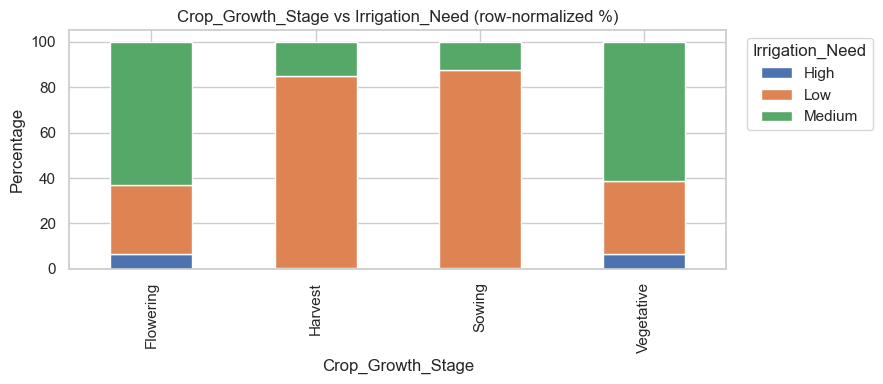

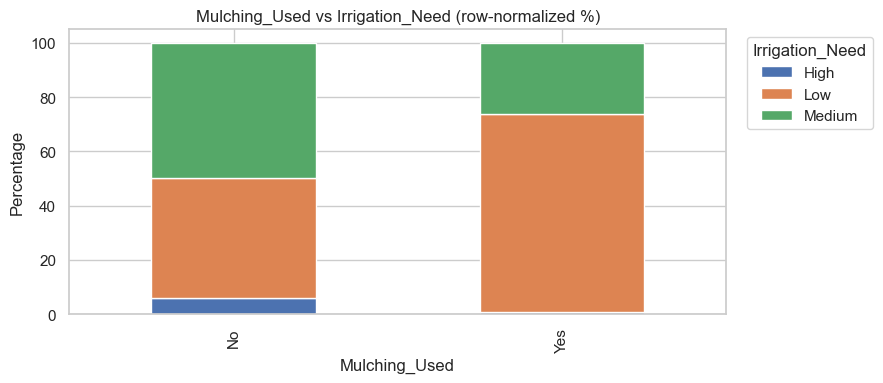

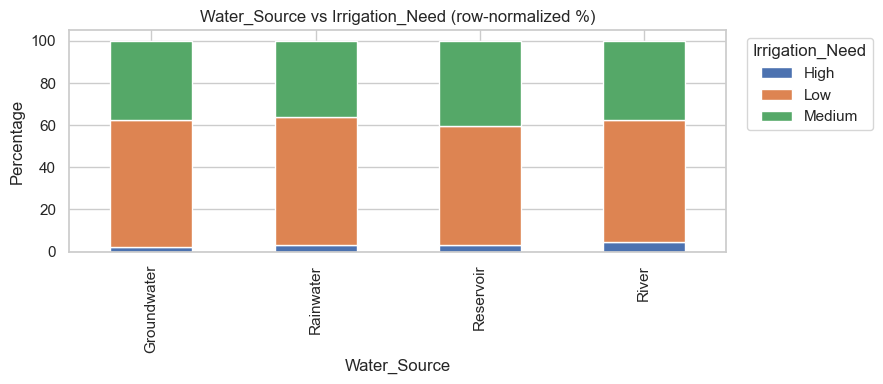

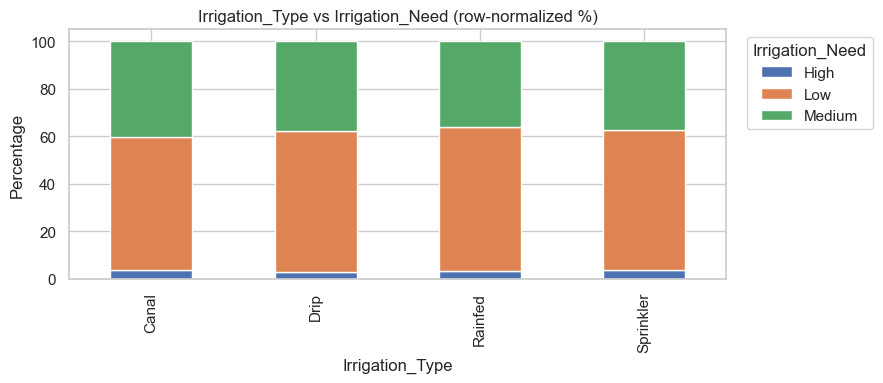

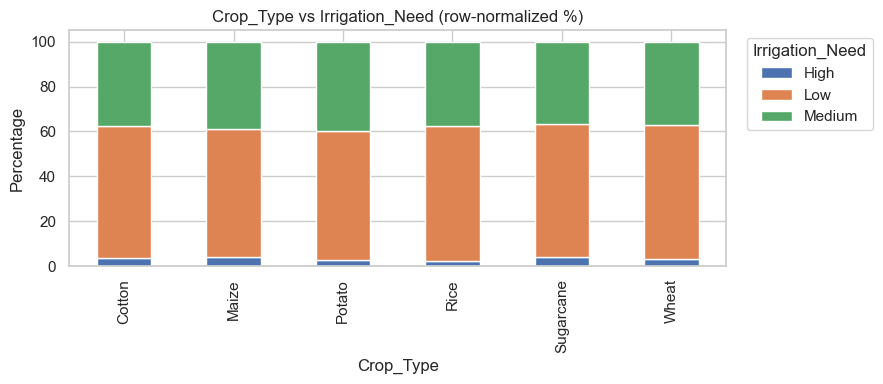

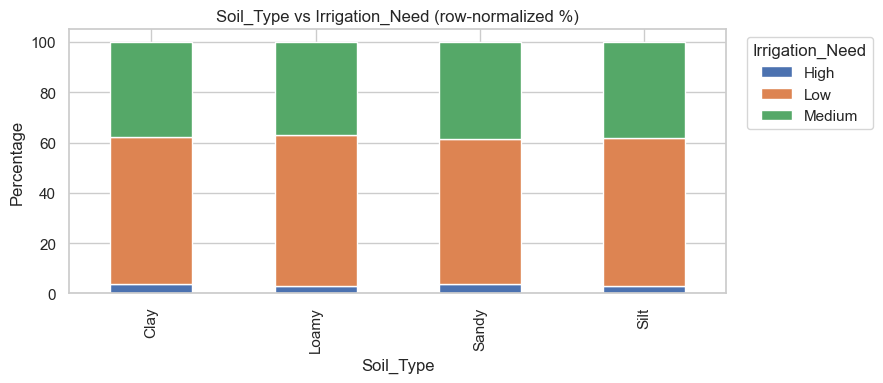

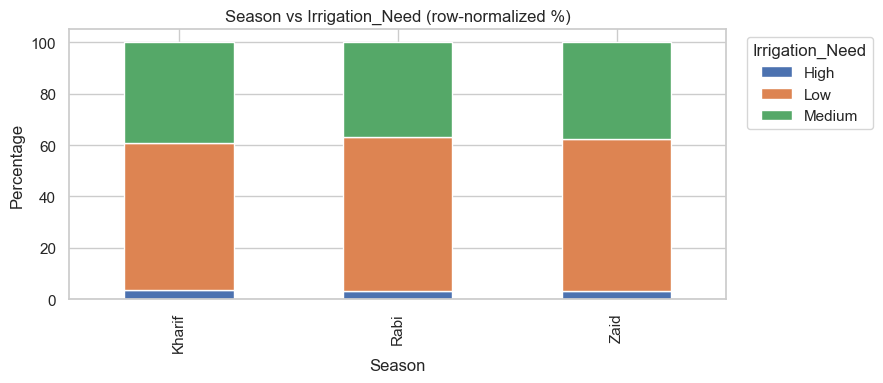

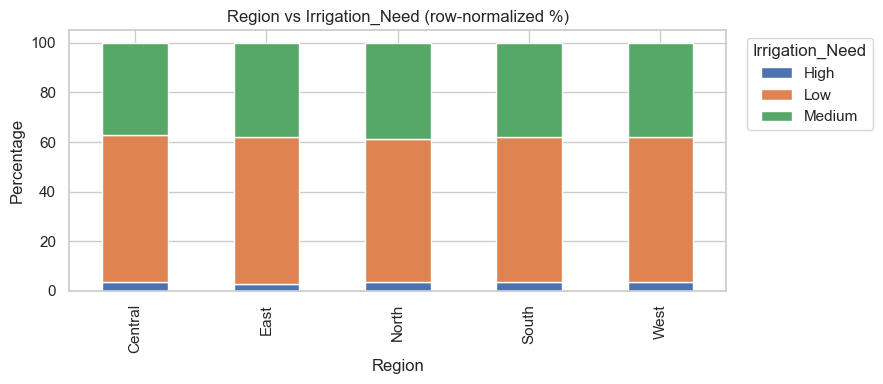

In [13]:
# =========================
# 5. CATEGORICAL FEATURES VS TARGET
#    Chi-square + Cramer's V + Stacked percentage plots
# =========================
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1)))) if min(r - 1, k - 1) > 0 else 0

cat_results = []
for col in cat_cols:
    ct = pd.crosstab(train[col], train[target])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v(train[col], train[target])
    cat_results.append([col, chi2, p, v])

cat_df = pd.DataFrame(cat_results, columns=["feature", "chi2", "p_value", "cramers_v"])
cat_df = cat_df.sort_values("cramers_v", ascending=False)

display(cat_df)

for col in cat_df["feature"]:
    prop = pd.crosstab(train[col], train[target], normalize="index") * 100
    prop.plot(kind="bar", stacked=True, figsize=(9,4))
    plt.title(f"{col} vs {target} (row-normalized %)")
    plt.ylabel("Percentage")
    plt.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [14]:
# =========================
# 6. QUICK FEATURE INSIGHTS
#    Top numeric and categorical signals
# =========================
print("Top numeric features by eta-squared:")
display(anova_df.head(5))

print("Top categorical features by Cramer's V:")
display(cat_df.head(5))

Top numeric features by eta-squared:


,feature,F_stat,p_value,eta_squared
1,Soil_Moisture,82555.917859,0.000000e+00,0.207659
8,Wind_Speed_kmh,22514.094175,0.000000e+00,0.066706
4,Temperature_C,22043.759085,0.000000e+00,0.065404
6,Rainfall_mm,7241.631185,0.000000e+00,0.022473
5,Humidity,172.297278,1.558475e-75,0.000547


Top categorical features by Cramer's V:


,feature,chi2,p_value,cramers_v
2,Crop_Growth_Stage,194378.520268,0.000000e+00,0.392771
6,Mulching_Used,56876.904242,0.000000e+00,0.300468
5,Water_Source,1642.705118,0.000000e+00,0.036107
4,Irrigation_Type,1096.452744,1.221198e-233,0.029499
1,Crop_Type,1094.944060,6.491332e-229,0.029479


In [15]:
# Map target to numeric
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
train['Irrigation_Need'] = train['Irrigation_Need'].map(target_map)

# Drop low-importance columns
drop_cols = ['id', 'Region', 'Field_Area_hectare', 'Organic_Carbon', 'Sunlight_Hours']
train.drop(columns=drop_cols, inplace=True, errors='ignore')
test.drop(columns=drop_cols, inplace=True, errors='ignore')

In [16]:
def bin_soil_moisture(df):
    bins = [-np.inf, 15, 25, np.inf]
    labels = ['Severe_Stress', 'Moderate_Stress', 'Adequate']
    df['Soil_Moisture_bin'] = pd.cut(df['Soil_Moisture'], bins=bins, labels=labels)
    return df

train = bin_soil_moisture(train)
test = bin_soil_moisture(test)

In [17]:
def add_interactions(df):
    df['Temp_Wind_Interaction'] = df['Temperature_C'] * df['Wind_Speed_kmh']
    df['Moisture_Temp_Interaction'] = df['Soil_Moisture'] * df['Temperature_C']
    return df

train = add_interactions(train)
test = add_interactions(test)

In [18]:
# Features lists
onehot_features = ['Soil_Type', 'Season', 'Mulching_Used', 'Soil_Moisture_bin']
target_encode_features = ['Crop_Type', 'Crop_Growth_Stage', 'Irrigation_Type', 'Water_Source']
numeric_features = ['Soil_pH', 'Soil_Moisture', 'Electrical_Conductivity', 'Temperature_C',
                    'Humidity', 'Rainfall_mm', 'Wind_Speed_kmh', 'Previous_Irrigation_mm',
                    'Temp_Wind_Interaction', 'Moisture_Temp_Interaction']

# Separate X and y
X = train.drop('Irrigation_Need', axis=1)
y = train['Irrigation_Need']
X_test = test.copy()

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")
# -------------------------
# Recover test ids
# -------------------------
test_original = pd.read_csv("C:/Users/DELL/Desktop/heart_disease/test.csv")
test_ids = test_original['id']

# ============================================================================
# 1. Feature engineering (same as before)
# ============================================================================
print("Creating features...")
X_raw = train.drop('Irrigation_Need', axis=1).copy()
y_raw = train['Irrigation_Need'].astype(str).str.strip()
if set(y_raw.unique()).issubset({'0','1','2'}):
    y = y_raw.astype(int)
else:
    target_map = {'Low':0,'Medium':1,'High':2}
    y = y_raw.map(target_map).fillna(0).astype(int)
X_test_raw = test.copy()

def add_features(df):
    df = df.copy()
    df['ET_proxy'] = df['Temperature_C'] * df['Wind_Speed_kmh'] * (1 - df['Humidity']/100)
    df['Water_Deficit'] = df['Rainfall_mm'] - df['ET_proxy'] * 2.5
    df['Moisture_Rainfall_Ratio'] = df['Soil_Moisture'] / (df['Rainfall_mm'] + 1e-3)
    df['PrevIrrig_Impact'] = df['Previous_Irrigation_mm'] * (1 + df['Soil_Moisture']/100)
    soil_capacity = {'Sandy':0.5, 'Loamy':1.0, 'Silt':1.2, 'Clay':1.5}
    df['Soil_Capacity'] = df['Soil_Type'].map(soil_capacity)
    df['Moisture_vs_Capacity'] = df['Soil_Moisture'] / (df['Soil_Capacity'] + 1e-3)
    df['Temp_Deviation'] = np.abs(df['Temperature_C'] - 25)
    df['Temp_Effectiveness'] = np.maximum(0, 30 - np.abs(df['Temperature_C'] - 25))
    df['Irrig_Efficiency'] = df['Previous_Irrigation_mm'] / (df['ET_proxy'] + 1)
    df['Wind_Humidity'] = df['Wind_Speed_kmh'] * (1 - df['Humidity']/100)
    stage_order = {'Sowing':0,'Vegetative':1,'Flowering':2,'Harvest':3}
    df['Stage_Ordinal'] = df['Crop_Growth_Stage'].map(stage_order)
    df['Moisture_x_Stage'] = df['Soil_Moisture'] * df['Stage_Ordinal']
    df.drop('Stage_Ordinal', axis=1, inplace=True)
    df['Crop_Stage_Combo'] = df['Crop_Type'].astype(str) + '_' + df['Crop_Growth_Stage'].astype(str)
    df['Humidity_Temp_Interaction'] = df['Humidity'] * df['Temperature_C'] / 100
    df['Rainfall_SoilMoisture'] = df['Rainfall_mm'] * df['Soil_Moisture'] / 100
    df.drop('Soil_Moisture_bin', axis=1, inplace=True, errors='ignore')
    return df

X = add_features(X_raw)
X_test = add_features(X_test_raw)

drop_cols = ['id','Region','Field_Area_hectare','Organic_Carbon','Sunlight_Hours']
X.drop(columns=drop_cols, inplace=True, errors='ignore')
X_test.drop(columns=drop_cols, inplace=True, errors='ignore')

# Convert categoricals
obj_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical features: {obj_cols}")
for c in obj_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')
cat_features = obj_cols

# ============================================================================
# 2. Class weights
# ============================================================================
classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
cw = {c:w for c,w in zip(classes, weights)}
sw = y.map(cw).values

# ============================================================================
# 3. Optuna objective – 3-fold CV for speed
# ============================================================================
def objective(trial):
    params = {
        'objective':'multiclass',
        'num_class':3,
        'metric':'multi_logloss',
        'boosting_type':'gbdt',
        'n_estimators':3000,
        'learning_rate':0.01,
        'num_leaves': trial.suggest_int('num_leaves', 20, 63),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 200, 500),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state':42,
        'n_jobs':-1,
        'verbose':-1
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        sw_tr = sw[tr_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
            categorical_feature=cat_features
        )
        proba = model.predict_proba(X_val)
        scores.append(log_loss(y_val, proba))
    return np.mean(scores)

print("\n--- Hyperparameter search (15 trials) ---")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15, show_progress_bar=True)
best_params = study.best_params
print("Best params:", best_params)

# ============================================================================
# 4. Retrain with best params on 5-fold OOF for threshold tuning
# ============================================================================
lgb_params = {
    'objective':'multiclass','num_class':3,'metric':'multi_logloss',
    'boosting_type':'gbdt',
    'n_estimators':3000,'learning_rate':0.01,
    **best_params,
    'random_state':42,'n_jobs':-1,'verbose':-1
}

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
oof_proba = np.zeros((len(X), 3))

print(f"\n=== {N_SPLITS}-fold CV with best params ===")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    sw_tr = sw[tr_idx]
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr, sample_weight=sw_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        categorical_feature=cat_features
    )
    oof_proba[val_idx] = model.predict_proba(X_val)
    acc = accuracy_score(y_val, np.argmax(oof_proba[val_idx], axis=1))
    print(f"Fold {fold+1}: Acc={acc:.5f}")

honest_acc = accuracy_score(y, np.argmax(oof_proba, axis=1))
print(f"\nHonest OOF accuracy (argmax): {honest_acc:.5f}")

# ============================================================================
# 5. Threshold tuning
# ============================================================================
print("Threshold tuning...")
best_acc, best_thresh = 0, (0.5,0.5)
for t_hi in np.arange(0.20, 0.50, 0.02):
    for t_md in np.arange(0.45, 0.65, 0.02):
        adj = oof_proba.copy()
        adj[:,2] *= t_hi/0.5
        adj[:,1] *= t_md/0.5
        adj = adj / adj.sum(axis=1, keepdims=True)
        acc = accuracy_score(y, np.argmax(adj, axis=1))
        if acc > best_acc:
            best_acc, best_thresh = acc, (t_hi, t_md)
print(f"Best OOF accuracy: {best_acc:.5f} (High={best_thresh[0]:.2f}, Med={best_thresh[1]:.2f})")

# ============================================================================
# 6. Retrain final model on full data & predict test
# ============================================================================
print("\nRetraining final model on full data...")
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, sample_weight=sw, categorical_feature=cat_features)

test_proba = final_model.predict_proba(X_test)

# apply thresholds
t_hi, t_md = best_thresh
test_proba_adj = test_proba.copy()
test_proba_adj[:,2] *= t_hi/0.5
test_proba_adj[:,1] *= t_md/0.5
test_proba_adj /= test_proba_adj.sum(axis=1, keepdims=True)
final_preds = np.argmax(test_proba_adj, axis=1)
# ============================================================================
# 10. SUBMISSION
# ============================================================================
target_map_rev = {0:'Low', 1:'Medium', 2:'High'}
test_labels = [target_map_rev[p] for p in final_preds]

sub = pd.DataFrame({'id': test_ids, 'Irrigation_Need': test_labels})
submission_path = 'C:/Users/DELL/Desktop/heart_disease/sample_submission.csv'
sub.to_csv(submission_path, index=False)
print(f"\n✅ Submission saved to {submission_path}")
print("First 5 rows:")
print(sub.head())

Creating features...
Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Crop_Stage_Combo']


[I 2026-04-28 12:17:41,788] A new study created in memory with name: no-name-668fa082-f33c-43da-92f6-4ee6430bcdec



--- Hyperparameter search (15 trials) ---


  0%|          | 0/15 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0656615
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0672638
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0647003
[I 2026-04-28 13:13:10,590] Trial 0 finished with value: 0.06587520809478999 and parameters: {'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 437, 'subsample': 0.7080702336612376, 'colsample_bytree': 0.5672529809211839, 'reg_alpha': 0.5828035350814712, 'reg_lambda': 0.564435451681092}. Best is trial 0 with value: 0.06587520809478999.
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0648337
Training until validation scores don't improve fo

Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0616785
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0595269
[I 2026-04-28 21:49:25,912] Trial 10 finished with value: 0.060570285530971844 and parameters: {'num_leaves': 63, 'max_depth': 7, 'min_child_samples': 336, 'subsample': 0.7483510100331118, 'colsample_bytree': 0.6006648931281166, 'reg_alpha': 0.6873898500239293, 'reg_lambda': 1.9344567618486608}. Best is trial 10 with value: 0.060570285530971844.
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.0605163
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's multi_logloss: 0.061695
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration i

In [44]:
#lol